In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, scipy.io as sio
import os, glob
from neo.io import BlackrockIO
import h5py

# Notes
preprocess (mostly notch filter) raw .mat

### global variables and functions

In [2]:
patient = 22

### lets consider example patient and channel

In [3]:
# load
chan_mat_files = glob.glob(f'../../results/*{patient}/osort_mat/nsx2mat/*.mat')
print(f'{len(chan_mat_files)} channels: ', end='')
for chan_mat_file in sorted(chan_mat_files):
    print(chan_mat_file.split('BL')[1].split('.mat')[0], end=', ')
# chan_mat_files

32 channels: 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 

#samples: 50569506
sampling freq: 30000.0
signal dur: 1685.6502


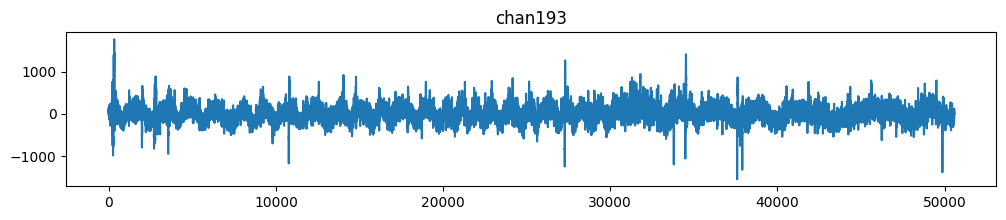

In [8]:
# example channel signal
chanID = 193
chan_mat_file = glob.glob(f'../../results/2025{patient}/osort_mat/nsx2mat/*{chanID}*.mat')[0]

# load
with h5py.File(chan_mat_file, "r") as f:

    raw_sig = np.array(f["data"]).squeeze()
    sig_freq = float(np.array(f["MetaTags/SamplingFreq"]).squeeze())
    sig_dur = raw_sig.shape[0] / sig_freq

print(f'#samples: {raw_sig.shape[0]}')
print(f'sampling freq: {sig_freq}')
print(f'signal dur: {sig_dur}')
every_nth = 1000  # for plotting
plt.figure(figsize=(12,2))
plt.plot(raw_sig[::every_nth])  # downsample for faster plotting
plt.title(f'chan{chanID}')
plt.show()

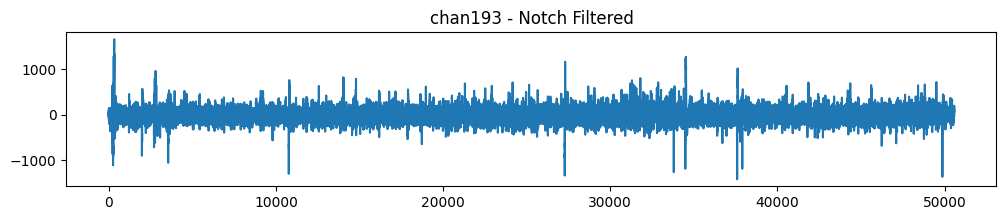

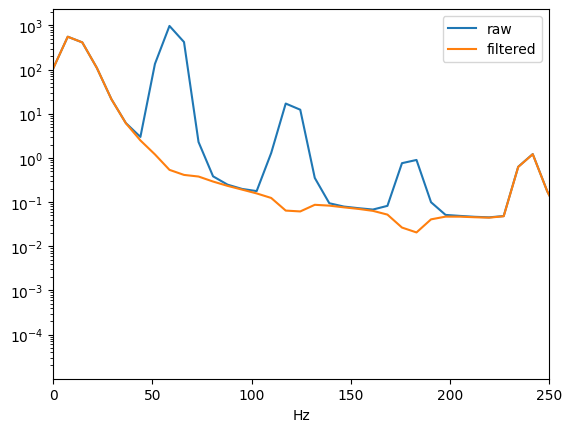

In [9]:
# notch filter at 60 Hz
from scipy.signal import iirnotch, filtfilt

def notch_filter(data, fs, freqs=[60.0, 120.0, 180.0], quality=30.0):
    filtered_data = data.copy()
    for freq in freqs:
        b, a = iirnotch(freq, quality, fs)
        filtered_data = filtfilt(b, a, filtered_data)
    return filtered_data

filtered_sig = notch_filter(raw_sig, sig_freq)
plt.figure(figsize=(12,2))
plt.plot(filtered_sig[::every_nth])  # downsample for faster plotting
plt.title(f'chan{chanID} - Notch Filtered')
plt.show()

from scipy.signal import welch
f, pxx_raw = welch(raw_sig, sig_freq, nperseg=4096)
f, pxx_filt = welch(filtered_sig, sig_freq, nperseg=4096)
plt.semilogy(f, pxx_raw, label='raw')
plt.semilogy(f, pxx_filt, label='filtered')
plt.xlim(0, 250); plt.legend(); plt.xlabel('Hz'); plt.show()

### great, now lets notch filter all channels and patients, and save

In [7]:
all_chan_mats = glob.glob(f'../../results/*/osort_mat/nsx2mat/*.mat')
print(len(all_chan_mats), 'total channels')

for chan_mat in sorted(all_chan_mats): # parse through all files
    patient = chan_mat.split('2025')[1].split('/')[0]
    chanID = int(chan_mat.split('BL')[1].split('.mat')[0])

    if patient != '21': continue  # only process pt22 for now

    # load .mat
    with h5py.File(chan_mat, "r") as f:
        raw_sig = np.array(f["data"]).squeeze()
        sig_freq = float(np.array(f["MetaTags/SamplingFreq"]).squeeze())

    # filter
    filtered_sig = notch_filter(raw_sig, sig_freq)
    
    # save
    out_dir = f'../../results/2025{patient}/osort_mat/nsx2mat_clean/'
    os.makedirs(out_dir, exist_ok=True)
    out_file = f'{out_dir}BL{chanID}.mat'

    # data must be row vector (1 x N) — getRawMATData tries h.data(1, from:to) first
    sio.savemat(
        f'{out_dir}BL{chanID}.mat',
        {'data': filtered_sig.reshape(1, -1)},
        format='5'   # v5 = no HDF5, avoids matfile() MetaTags/SamplingFreq crash
    )
    print(f'pt{patient}/chan{chanID}', end=', ')

print('done')

128 total channels
pt21/chan193, pt21/chan194, pt21/chan195, pt21/chan196, pt21/chan197, pt21/chan198, pt21/chan199, pt21/chan200, pt21/chan201, pt21/chan202, pt21/chan203, pt21/chan204, pt21/chan205, pt21/chan206, pt21/chan207, pt21/chan208, pt21/chan209, pt21/chan210, pt21/chan211, pt21/chan212, pt21/chan213, pt21/chan214, pt21/chan215, pt21/chan216, pt21/chan217, pt21/chan218, pt21/chan219, pt21/chan220, pt21/chan221, pt21/chan222, pt21/chan223, pt21/chan224, done
